# **Análisis de Señales de EEG para Imaginería Motora**

**Estudiante** Mariana Vásquez Ramírez

### **Resumen** 

En este trabajo se realizó el análisis de señales electroencefalográficas (EEG) registradas durante tareas de imaginería motora de mano izquierda y mano derecha con el objetivo de identificar canales cerebrales que aporten información diferencial para el desarrollo de interfaces cerebro-computadora (BCI). Inicialmente se cargaron y procesaron las señales EEG correspondientes a múltiples sujetos y se segmentaron en épocas asociadas a cada tarea motora. Posteriormente se implementó una función para calcular el valor RMS (Root Mean Square) de cada época y canal a lo largo del tiempo, obteniendo así un valor representativo por canal para cada sujeto.

A partir de estos valores se construyó una base de datos poblacional donde las filas correspondieron a los sujetos analizados y las columnas a los canales EEG registrados. Con el fin de identificar diferencias entre ambas tareas motoras, se realizó un análisis estadístico canal por canal. En primer lugar, se evaluó la normalidad de los datos mediante la prueba de Shapiro-Wilk y posteriormente la homogeneidad de varianzas mediante la prueba de Levene. Debido a que en la mayoría de los casos no se cumplió el supuesto de normalidad, se aplicó la prueba no paramétrica U de Mann-Whitney para comparar los valores RMS entre las condiciones de imaginería de mano izquierda y mano derecha.

Los resultados obtenidos mostraron que ningún canal presentó valores p inferiores a 0.05, lo que indica que no se encontraron diferencias estadísticamente significativas entre ambas condiciones utilizando la métrica RMS promedio. Finalmente, se realizó una visualización mediante diagramas de caja (boxplot) para el canal con el menor p-valor, permitiendo comparar gráficamente la distribución de los valores RMS entre ambos grupos poblacionales. Este análisis constituye un paso inicial en la identificación de características relevantes en señales EEG para aplicaciones de interfaces cerebro-computadora.

### **Teoría**

**Electroencefalografía (EEG)**

La electroencefalografía (EEG) es una técnica no invasiva que permite registrar la actividad eléctrica del cerebro mediante electrodos colocados sobre el cuero cabelludo. Esta actividad eléctrica refleja principalmente la suma de los potenciales postsinápticos generados por poblaciones de neuronas corticales.

Las señales EEG presentan amplitudes del orden de microvoltios (µV) y contienen información sobre diferentes procesos cognitivos y motores. Debido a su alta resolución temporal, el EEG es ampliamente utilizado en aplicaciones de neurociencia, diagnóstico clínico y desarrollo de interfaces cerebro-computadora (BCI).

Los electrodos EEG se colocan siguiendo el sistema internacional 10-20, el cual estandariza las posiciones de registro sobre el cuero cabelludo. En estudios de imaginería motora son especialmente relevantes los electrodos ubicados sobre la corteza motora, como C3, Cz y C4, ya que estos reflejan la actividad relacionada con el control de movimientos voluntarios.[1]

**Imaginería motora**

La imaginería motora consiste en la simulación mental de un movimiento sin ejecutarlo físicamente. Durante este proceso se activan regiones corticales similares a las involucradas en la ejecución real del movimiento, particularmente en la corteza motora primaria.

En el caso de tareas como imaginar el movimiento de la mano izquierda o derecha, se observa una lateralización de la actividad cerebral:

Imaginería de mano izquierda → activación en el hemisferio derecho
Imaginería de mano derecha → activación en el hemisferio izquierdo

Este fenómeno es ampliamente utilizado en sistemas BCI, donde la actividad cerebral registrada mediante EEG se procesa para traducir la intención motora del usuario en comandos para dispositivos externos.[2]

**Interfaces cerebro-computadora (BCI)**

Una interfaz cerebro-computadora (BCI) es un sistema que permite establecer una comunicación directa entre el cerebro y un dispositivo externo sin la participación de los músculos periféricos.

Un sistema BCI típico consta de las siguientes etapas:

- Adquisición de la señal cerebral
- Preprocesamiento
- Extracción de características
- Clasificación
- Generación de comandos

En sistemas basados en imaginería motora, la extracción de características suele realizarse mediante métricas que permiten describir la energía o variabilidad de la señal EEG en diferentes canales o bandas de frecuencia.[3]



In [1]:
# Instalamos las librerías necesarias para trabajar con señales de EEG

%pip install mne autoreject

# MNE es la librería especializada en señales de EEG en Python
# Nos permite descargar, cargar y procesar señales cerebrales fácilmente

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importamos las librerías necesarias, incluyendo MNE para el procesamiento de EEG y NumPy para cálculos numéricos

import mne
import numpy as np

# Definimos una función para calcular el valor RMS de las señales de EEG, que es una medida común de la potencia de la señal.

def calcular_rms(data):
    """ Calcula el valor RMS de las señales de EEG.
    Args:       data (numpy.ndarray): Array de forma (n_epochs, n_channels, n_times)
    Returns:    rms_epocas (numpy.ndarray): Array de forma (n_epochs, n_channels) con el RMS de cada época
                rms_promedio (numpy.ndarray): Array de forma (n_channels,) con el RMS promedio de todas las épocas
    """
    rms_epocas = np.sqrt(np.mean(data**2, axis=2))
    rms_promedio = np.mean(rms_epocas, axis=0)

    return rms_epocas, rms_promedio

In [3]:
# Definimos los sujetos y las ejecuciones que vamos a procesar. 
# En este caso, tenemos 10 sujetos y 3 ejecuciones (4, 8 y 12) que corresponden a diferentes tareas de movimiento de manos. 
# Cada ejecución tiene un número específico de eventos que representan las tareas de movimiento de la mano izquierda (T1) y la mano derecha (T2).

subjects = list(range(1,11)) # Lista de sujetos del 1 al 10
runs = [4,8,12] 

RMS_T1 = [] # Lista para almacenar los valores RMS de la tarea T1 (mano izquierda) de cada sujeto
RMS_T2 = [] # Lista para almacenar los valores RMS de la tarea T2 (mano derecha) de cada sujeto

# Procesamos cada sujeto, cargando sus datos de EEG, extrayendo las épocas correspondientes a las tareas T1 y T2, y calculando el valor RMS para cada tarea.

for subject in subjects:

    print(f"\nProcesando sujeto S{subject:03d}") 
    #:03d formatea el número del sujeto con ceros a la izquierda para mantener un formato uniforme (por ejemplo, S001, S002, etc.)

    # Carga los archivos de datos de EEG para el sujeto y las ejecuciones especificadas
    raw_files = mne.datasets.eegbci.load_data(subject, runs) 
    #mne.datasets.eegbci.load_data es una función de MNE que descarga y carga los datos de EEG para un sujeto y ejecuciones específicas. 
    # Se le pasa el número del sujeto y la lista de ejecuciones, y devuelve una lista de rutas a los archivos de datos de EEG en formato EDF.

    raws = [] # Lista para almacenar los objetos Raw de MNE para cada archivo de datos

    # Leemos cada archivo de datos de EEG utilizando MNE y los almacenamos en la lista raws.
    for f in raw_files:
        raw = mne.io.read_raw_edf(f, preload=True) 
        # mne.io.read_raw_edf es una función de MNE que lee un archivo de datos de EEG en formato EDF y devuelve un objeto Raw que contiene los datos de EEG.
        raws.append(raw)

    # Concatenamos los objetos Raw de MNE para obtener un solo objeto Raw que contenga todos los datos de EEG del sujeto.
    raw = mne.concatenate_raws(raws) 

    # mne.events_from_annotations extrae los eventos de las anotaciones en el objeto Raw, lo que nos permitirá segmentar los datos en épocas correspondientes a las tareas T1 y T2.
    #events es un array que contiene la información de los eventos (tiempo, tipo de evento, etc.) 
    # y event_dict es un diccionario que mapea los nombres de los eventos a sus códigos numéricos.
    events, event_dict = mne.events_from_annotations(raw) 

    # Creamos las épocas para las tareas T1 y T2 utilizando la función mne.Epochs, 
    # especificando los eventos correspondientes a cada tarea, el intervalo de tiempo para cada época (de 0 a 4 segundos), y cargando los datos en memoria para su procesamiento posterior.
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1':2,'T2':3},
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True
    )

    epochs_T1 = epochs['T1'] 
    epochs_T2 = epochs['T2']

    data_T1 = epochs_T1.get_data()
    data_T2 = epochs_T2.get_data()

    print("Dimensiones T1:", data_T1.shape)
    print("Dimensiones T2:", data_T2.shape)

    # calcular RMS
    _, rms_T1 = calcular_rms(data_T1)
    _, rms_T2 = calcular_rms(data_T2)

    RMS_T1.append(rms_T1)
    RMS_T2.append(rms_T2)




Procesando sujeto S001


c:\Users\MARIANA\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Extracting EDF parameters from C:\Users\MARIANA\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\MARIANA\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from C:\Users\MARIANA\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: ['T0', 'T1', 'T2']
Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 641 original time points ...
0 bad epochs dropped
Dimensiones T1: (23, 64, 641)
Dimensiones

In [4]:
# Finalmente, convertimos las listas de RMS en matrices NumPy para facilitar su análisis y visualización posterior.

RMS_T1 = np.vstack(RMS_T1)
RMS_T2 = np.vstack(RMS_T2)

print("\nRESULTADOS FINALES")
print("Matriz RMS Mano Izquierda:", RMS_T1.shape)
print("Matriz RMS Mano Derecha:", RMS_T2.shape)


RESULTADOS FINALES
Matriz RMS Mano Izquierda: (10, 64)
Matriz RMS Mano Derecha: (10, 64)


In [5]:
import pandas as pd

# obtener nombres de canales
canales = epochs.ch_names

# crear nombres de sujetos
subjects_names = [f"S{i:03d}" for i in range(1,11)]

# Creamos DataFrames de Pandas para organizar los valores RMS de las tareas T1 y T2, 
# utilizando los nombres de los canales como columnas y los nombres de los sujetos como índices.
df_T1 = pd.DataFrame(
    RMS_T1,
    columns=canales,
    index=subjects_names
)

df_T2 = pd.DataFrame(
    RMS_T2,
    columns=canales,
    index=subjects_names
)

print("\nDataFrame Mano Izquierda")
print(df_T1.head())


DataFrame Mano Izquierda
          Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.      Fc6.  \
S001  0.000046  0.000047  0.000049  0.000052  0.000049  0.000043  0.000038   
S002  0.000021  0.000020  0.000020  0.000021  0.000019  0.000018  0.000016   
S003  0.000068  0.000065  0.000061  0.000061  0.000060  0.000060  0.000061   
S004  0.000031  0.000027  0.000037  0.000026  0.000025  0.000024  0.000024   
S005  0.000064  0.000028  0.000044  0.000041  0.000033  0.000040  0.000040   

          C5..      C3..      C1..  ...      P8..      Po7.      Po3.  \
S001  0.000047  0.000047  0.000049  ...  0.000037  0.000048  0.000049   
S002  0.000021  0.000020  0.000021  ...  0.000013  0.000020  0.000022   
S003  0.000054  0.000055  0.000054  ...  0.000044  0.000054  0.000053   
S004  0.000028  0.000030  0.000032  ...  0.000021  0.000022  0.000023   
S005  0.000037  0.000041  0.000037  ...  0.000040  0.000040  0.000035   

          Poz.      Po4.      Po8.      O1..      Oz..      O2..  

In [6]:
print("\nDataFrame Mano Derecha")
print(df_T2.head())


DataFrame Mano Derecha
          Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.      Fc6.  \
S001  0.000061  0.000059  0.000060  0.000061  0.000055  0.000047  0.000042   
S002  0.000022  0.000021  0.000021  0.000021  0.000020  0.000018  0.000016   
S003  0.000066  0.000059  0.000059  0.000060  0.000059  0.000058  0.000058   
S004  0.000026  0.000025  0.000042  0.000025  0.000025  0.000023  0.000023   
S005  0.000068  0.000031  0.000046  0.000043  0.000035  0.000041  0.000041   

          C5..      C3..      C1..  ...      P8..      Po7.      Po3.  \
S001  0.000058  0.000055  0.000058  ...  0.000039  0.000052  0.000054   
S002  0.000021  0.000020  0.000022  ...  0.000013  0.000019  0.000021   
S003  0.000051  0.000055  0.000053  ...  0.000039  0.000049  0.000049   
S004  0.000026  0.000030  0.000030  ...  0.000019  0.000021  0.000023   
S005  0.000039  0.000043  0.000041  ...  0.000040  0.000039  0.000037   

          Poz.      Po4.      Po8.      O1..      Oz..      O2..    

### **Análisis**

A partir de los valores RMS promedio obtenidos para cada sujeto y canal EEG, se construyó una base de datos poblacional utilizando DataFrame. En estas tablas, las filas corresponden a cada sujeto analizado y las columnas corresponden a los canales EEG registrados (64 canales). Cada celda contiene el valor RMS promedio calculado para el canal correspondiente. Se generaron dos bases de datos independientes: una para la imaginería motora de mano izquierda (T1) y otra para la imaginería motora de mano derecha (T2), lo que permite comparar posteriormente las diferencias en la actividad cerebral asociadas a cada condición.

In [7]:
# Verificamos que los índices de ambos DataFrames sean iguales, lo que es importante para compararlos correctamente.
print(df_T1.index)
print(df_T2.index)

Index(['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009',
       'S010'],
      dtype='object')
Index(['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009',
       'S010'],
      dtype='object')


In [8]:
# Realizamos pruebas estadísticas para comparar los valores RMS entre las tareas T1 y T2 para cada canal.
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

canales = df_T1.columns

p_normalidad_T1 = []
p_normalidad_T2 = []
p_levene = []
p_prueba = []
test_usado = []

for canal in canales:
    
    datos_T1 = df_T1[canal]
    datos_T2 = df_T2[canal]
    
    # -------- PRUEBA DE NORMALIDAD --------
    stat1, p1 = shapiro(datos_T1)
    stat2, p2 = shapiro(datos_T2)
    
    p_normalidad_T1.append(p1)
    p_normalidad_T2.append(p2)
    
    # -------- PRUEBA DE HOMOCEDASTICIDAD --------
    stat_lev, p_lev = levene(datos_T1, datos_T2)
    p_levene.append(p_lev)
    
    # -------- SELECCIÓN DE PRUEBA --------
    if (p1 > 0.05) and (p2 > 0.05) and (p_lev > 0.05):
        
        # t-test
        stat, p = ttest_ind(datos_T1, datos_T2)
        test_usado.append("t-test")
    
    else:
        
        # Mann Whitney
        stat, p = mannwhitneyu(datos_T1, datos_T2)
        test_usado.append("Mann-Whitney")
    
    p_prueba.append(p) 
    # Guardamos el valor p de la prueba estadística para cada canal en la lista p_prueba.

In [9]:
# Finalmente, organizamos todos los resultados en un DataFrame de Pandas para facilitar su interpretación y análisis posterior.
resultados = pd.DataFrame({
    "Canal": canales,
    "p_Normalidad_T1": p_normalidad_T1,
    "p_Normalidad_T2": p_normalidad_T2,
    "p_Levene": p_levene,
    "Prueba_usada": test_usado,
    "p_value": p_prueba
})

In [10]:
print(resultados)

   Canal  p_Normalidad_T1  p_Normalidad_T2  p_Levene  Prueba_usada   p_value
0   Fc5.         0.011304         0.003810  0.809222  Mann-Whitney  0.909722
1   Fc3.         0.012493         0.003006  0.922482  Mann-Whitney  0.969850
2   Fc1.         0.001122         0.000307  0.897822  Mann-Whitney  0.850107
3   Fcz.         0.003937         0.000923  0.861848  Mann-Whitney  1.000000
4   Fc2.         0.057441         0.017159  0.860253  Mann-Whitney  1.000000
..   ...              ...              ...       ...           ...       ...
59  Po8.         0.000174         0.000032  0.844540  Mann-Whitney  0.969850
60  O1..         0.000965         0.000184  0.849902  Mann-Whitney  0.969850
61  Oz..         0.000799         0.000127  0.864008  Mann-Whitney  0.969850
62  O2..         0.000117         0.000045  0.869989  Mann-Whitney  0.969850
63  Iz..         0.066711         0.040136  0.972684  Mann-Whitney  0.969850

[64 rows x 6 columns]


### **Análisis**

El análisis estadístico se realizó sobre 64 canales de EEG con el objetivo de determinar si existen diferencias significativas entre las tareas de imaginería motora de mano izquierda (T1) y mano derecha (T2). Para ello, se siguió un flujo de validación que incluyó pruebas de normalidad (Shapiro-Wilk), homocedasticidad (Levene) y posteriormente una prueba de hipótesis adecuada según los supuestos estadísticos.

En primer lugar, los resultados de la prueba de Shapiro-Wilk muestran que, en la mayoría de los canales, los p-valores son menores a 0.05, lo que indica que las distribuciones de los datos para ambos grupos no siguen una distribución normal. Debido a la violación del supuesto de normalidad, no fue apropiado aplicar una prueba paramétrica como la t de Student.

Posteriormente, la prueba de Levene arrojó valores de p mayores a 0.05 en la mayoría de los canales, lo que sugiere que las varianzas entre ambos grupos son similares. Sin embargo, dado que no se cumple el supuesto de normalidad, se optó por utilizar la prueba no paramétrica U de Mann-Whitney para comparar las distribuciones entre las tareas T1 y T2.

Los resultados de la prueba de Mann-Whitney muestran que los p-valores obtenidos son significativamente mayores a 0.05 en todos los canales, lo que indica que no existen diferencias estadísticamente significativas entre las señales EEG asociadas a la imaginería motora de la mano izquierda y derecha cuando se analiza la característica RMS promedio.

En consecuencia, ningún canal puede considerarse estadísticamente diferencial para discriminar entre ambas tareas dentro del conjunto de datos analizado. Esto sugiere que la característica RMS utilizada puede no ser suficientemente sensible para capturar las variaciones específicas de la actividad cerebral asociada a la imaginería motora, o que la variabilidad entre sujetos reduce la capacidad de detectar diferencias claras entre condiciones.

In [11]:
# Mostramos el DataFrame con los resultados de las pruebas estadísticas para cada canal, 
# incluyendo los valores p de normalidad, homocedasticidad y la prueba utilizada.
canales_significativos = resultados[resultados["p_value"] < 0.05]

print("Canales con diferencia significativa:")
print(canales_significativos)

Canales con diferencia significativa:
Empty DataFrame
Columns: [Canal, p_Normalidad_T1, p_Normalidad_T2, p_Levene, Prueba_usada, p_value]
Index: []


### **Análisis**

El análisis estadístico realizado no identificó canales con diferencias estadísticamente significativas entre las tareas de imaginería motora de mano izquierda (T1) y mano derecha (T2), ya que ningún canal presentó un p-valor menor a 0.05. Por esta razón, el conjunto de resultados filtrado aparece como un DataFrame vacío.


In [12]:
# Identificamos el canal con la diferencia más significativa entre las tareas T1 y T2, 
# es decir, el canal con el valor p más bajo.
# .sort_values("p_value") ordena el DataFrame por la columna "p_value" de menor a mayor, 
# y .iloc[0] selecciona la primera fila, que corresponde al canal con el valor p más bajo.
canal_mas_significativo = resultados.sort_values("p_value").iloc[0]
print(canal_mas_significativo)


Canal                      F8..
p_Normalidad_T1        0.009304
p_Normalidad_T2        0.016839
p_Levene               0.819316
Prueba_usada       Mann-Whitney
p_value                 0.73373
Name: 37, dtype: object


C:\Users\MARIANA\AppData\Local\Temp\ipykernel_9120\3407765923.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos, labels=["Mano Izquierda", "Mano Derecha"])


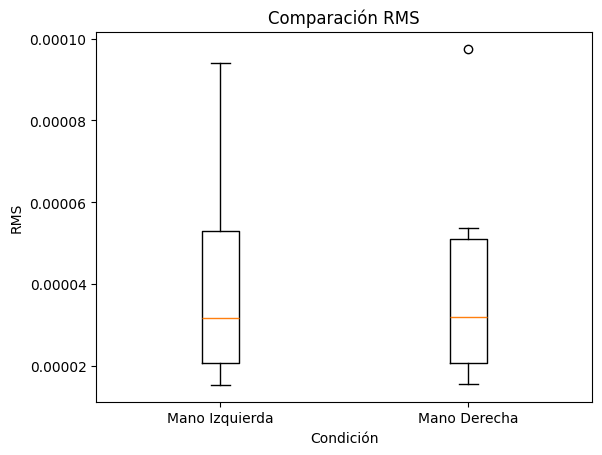

In [13]:
# Visualizamos los resultados utilizando un gráfico de caja (boxplot) 
# para comparar los valores RMS entre las tareas T1 y T2 para el canal con la diferencia más significativa.
import matplotlib.pyplot as plt

datos = [
    df_T1[canal],
    df_T2[canal]
]

plt.figure()
plt.boxplot(datos, labels=["Mano Izquierda", "Mano Derecha"])

plt.title("Comparación RMS")
plt.ylabel("RMS")
plt.xlabel("Condición")

plt.show()

### **Análisis**

El diagrama de caja presenta la comparación de la distribución del valor RMS de la señal EEG entre las condiciones de imaginería motora de mano izquierda y mano derecha. A partir de la visualización se pueden identificar varios aspectos importantes del comportamiento de los datos.

En primer lugar, las medianas de ambas distribuciones son muy similares, ubicándose aproximadamente alrededor de 3.0 * 10^-5. Esto indica que el nivel promedio de energía de la señal EEG, representado por el RMS, no difiere notablemente entre las dos condiciones experimentales.

En segundo lugar, el rango intercuartílico (IQR) de ambas cajas también es bastante parecido. Esto sugiere que la variabilidad central de los datos es similar tanto para la imaginería de la mano izquierda como para la de la mano derecha.

Además, en la condición de mano derecha se identifica un valor atípico (outlier) cercano a 
1.0 * 10^-4, lo que representa un sujeto o medición con un valor de RMS notablemente mayor al resto de la población.

En conjunto, la fuerte superposición entre las distribuciones, la similitud en las medianas y la cercanía en los rangos de dispersión sugieren que no existe una diferencia clara entre ambas condiciones en términos del RMS de la señal EEG. Este comportamiento visual es consistente con los resultados estadísticos obtenidos previamente, donde ningún canal presentó diferencias significativas (p < 0.05) entre las tareas de imaginería motora.

### **Conclusiones**

- Se logró procesar y analizar las señales de electroencefalografía (EEG) correspondientes a tareas de imaginería motora de mano izquierda y mano derecha, calculando el valor RMS promedio por canal para cada sujeto. Este procedimiento permitió obtener una representación cuantitativa de la actividad eléctrica cerebral registrada en los diferentes electrodos.
- Los resultados mostraron que ningún canal presentó un p-valor menor a 0.05, lo que indica que no se encontraron diferencias estadísticamente significativas entre ambas condiciones en términos del RMS promedio de las señales EEG analizadas. En consecuencia, dentro del conjunto de datos evaluado, no se identificaron canales diferenciales claros para el control de una interfaz cerebro-computadora (BCI) utilizando únicamente esta característica.
- Aunque el procedimiento permitió estructurar correctamente la base de datos, extraer características y aplicar análisis estadístico riguroso, la métrica RMS por sí sola puede no ser suficiente para discriminar las tareas de imaginería motora. Por lo tanto, futuros trabajos podrían incorporar otras técnicas de procesamiento de señales para mejorar la identificación de patrones diferenciales en aplicaciones de BCI.

### **Referencias**

[1] S. Sanei and J. A. Chambers, EEG Signal Processing. Chichester, UK: John Wiley & Sons, 2007..Enlace:https://faculty.washington.edu/seattle/brain-physics/textbooks/sanei.pdf

[2] J. Decety, “The neurophysiological basis of motor imagery,” Behavioral Brain Research, vol. 77, no. 1–2, pp. 45–52, 1996. doi: 10.1016/0166-4328(95)00225-1. Enlace: https://pubmed.ncbi.nlm.nih.gov/8762158/

[3] Shih JJ, Krusienski DJ, Wolpaw JR. Brain-computer interfaces in medicine. Mayo Clin Proc. 2012 Mar;87(3):268-79. doi: 10.1016/j.mayocp.2011.12.008. Epub 2012 Feb 10. PMID: 22325364; PMCID: PMC3497935. Enlace: https://pmc.ncbi.nlm.nih.gov/articles/PMC3497935/